In [28]:
# environment: /ix/djishnu/alw399/envs/sheep/bin/python
# import SpaceTravLR

In [45]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [46]:
training_data = '/ix/djishnu/shared/djishnu_kor11/training_data_2025'
adata = sc.read_h5ad(training_data + '/mouse_lymph1a_visiumHD.h5ad')
adata

AnnData object with n_obs × n_vars = 22324 × 2116
    obs: 'sample', 'cell_type', 'secondary_annot', 'cell_type_int'
    uns: 'cell_thresholds', 'cell_type_colors', 'neighbors', 'received_ligands', 'received_ligands_tfl', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_features', 'spatial_maps', 'spatial_unscaled'
    layers: 'imputed_count', 'normalized_count', 'raw_count'
    obsp: 'connectivities', 'distances'

In [47]:
betadir = '/ix/djishnu/shared/djishnu_kor11/lasso_runs/'
betadirs = [betadir + f'mouse_lymph1{letter}_visiumHD' for letter in 'abcd']

### Visualization

In [48]:
network_genes = np.loadtxt('network_genes.txt', dtype=str)
len(network_genes)

290

In [49]:
tfh_markers = {
    # 'base_markers': ['Il21', 'Cxcr5', 'Pdcd1', 'Bcl6']
    'base_markers': ['Cxcr5', 'Pdcd1', 'Bcl6']
} 

if 'Il21' in tfh_markers['base_markers']:
    suffix = '_Il21'
else:
    suffix = ''

suffix

''

In [50]:
all_markers = np.loadtxt('all_markers.txt', dtype=str)
all_markers = [x for x in all_markers if x in adata.var_names]
len(all_markers)

529

In [51]:
from tqdm import tqdm
import os 

betadir = '/ix/djishnu/shared/djishnu_kor11/lasso_runs/'
data = {}

for gene in tqdm(tfh_markers['base_markers']):

    betas = []

    for part in ['a', 'b', 'c', 'd']:
        if os.path.exists(betadir + f'mouse_lymph1{part}_visiumHD/' + gene + '_betadata.parquet'):
            betas.append(pd.read_parquet(betadir + f'mouse_lymph1{part}_visiumHD/' + gene + '_betadata.parquet'))
    
    if len(betas) > 0:
        data[gene] = pd.concat(betas)

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 13.03it/s]


In [52]:
interactions = {}

for key in tqdm(tfh_markers.keys()):
    interactions[key] = {}
    for gene in tfh_markers[key]:
        if gene in data:
            interactions[key][gene] = data[gene].loc[
                adata[adata.obs['cell_type'] == 'Tfh'].obs.index
            ]

100%|██████████| 1/1 [00:00<00:00, 34.27it/s]


In [53]:
tfh_markers.keys()

dict_keys(['base_markers'])

In [54]:
key_name = 'base_markers'
target_genes = tfh_markers[key_name]

In [55]:
dfr = pd.concat([interactions[key_name][gene] for gene in set(target_genes) & set(data.keys())], axis=1)
dfr = dfr.groupby(dfr.columns, axis=1).sum()
dfr = dfr[[x for x in dfr.columns if '$' in x]].fillna(0)
receptors = [x.split('$')[1] for x in dfr.columns]
ligands = [x.split('$')[0] for x in dfr.columns]
ligands = [x.replace('beta_', '') for x in ligands]
beta = dfr

th2_expr = adata[dfr.index, receptors].to_df(layer='imputed_count')
th2_expr = np.where(adata.uns['cell_thresholds'].loc[beta.index, receptors] > 0, th2_expr, 0)
env_expr = adata.uns['received_ligands'].loc[dfr.index, ligands]
env_expr = np.where(adata.uns['cell_thresholds'].loc[dfr.index, ligands] > 0, env_expr, 0)

wbetas = beta * th2_expr * env_expr
wbetas.columns = [x.replace('$', '-') for x in wbetas.columns]

/tmp/ipykernel_79775/107821873.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  dfr = dfr.groupby(dfr.columns, axis=1).sum()


In [56]:
drop_cols = [x for x in wbetas.columns if 'Cd4' in x]
wbetas = wbetas.drop(columns=drop_cols)

In [57]:
# exclude = [x for x in wbetas.columns if 'Mif' in x]
# wbetas = wbetas.drop(columns=exclude)

In [58]:
wbetas.sum().sort_values(ascending=False, key=abs).head(10)

beta_C3-Itgb2       -0.018163
beta_Ccl21a-Ccr7    -0.001887
beta_Lgals9-Ighm    -0.001439
beta_Mif-Cd74       -0.000987
beta_Lgals9-Ptprc   -0.000539
beta_Ccl5-Ccr4      -0.000276
beta_Ccl22-Ccr4     -0.000184
beta_Tgfb1-Tgfbr2    0.000080
beta_Tgfb1-Tgfbr1   -0.000079
beta_Clcf1-Il6st     0.000047
dtype: float64

/tmp/ipykernel_79775/3942392254.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


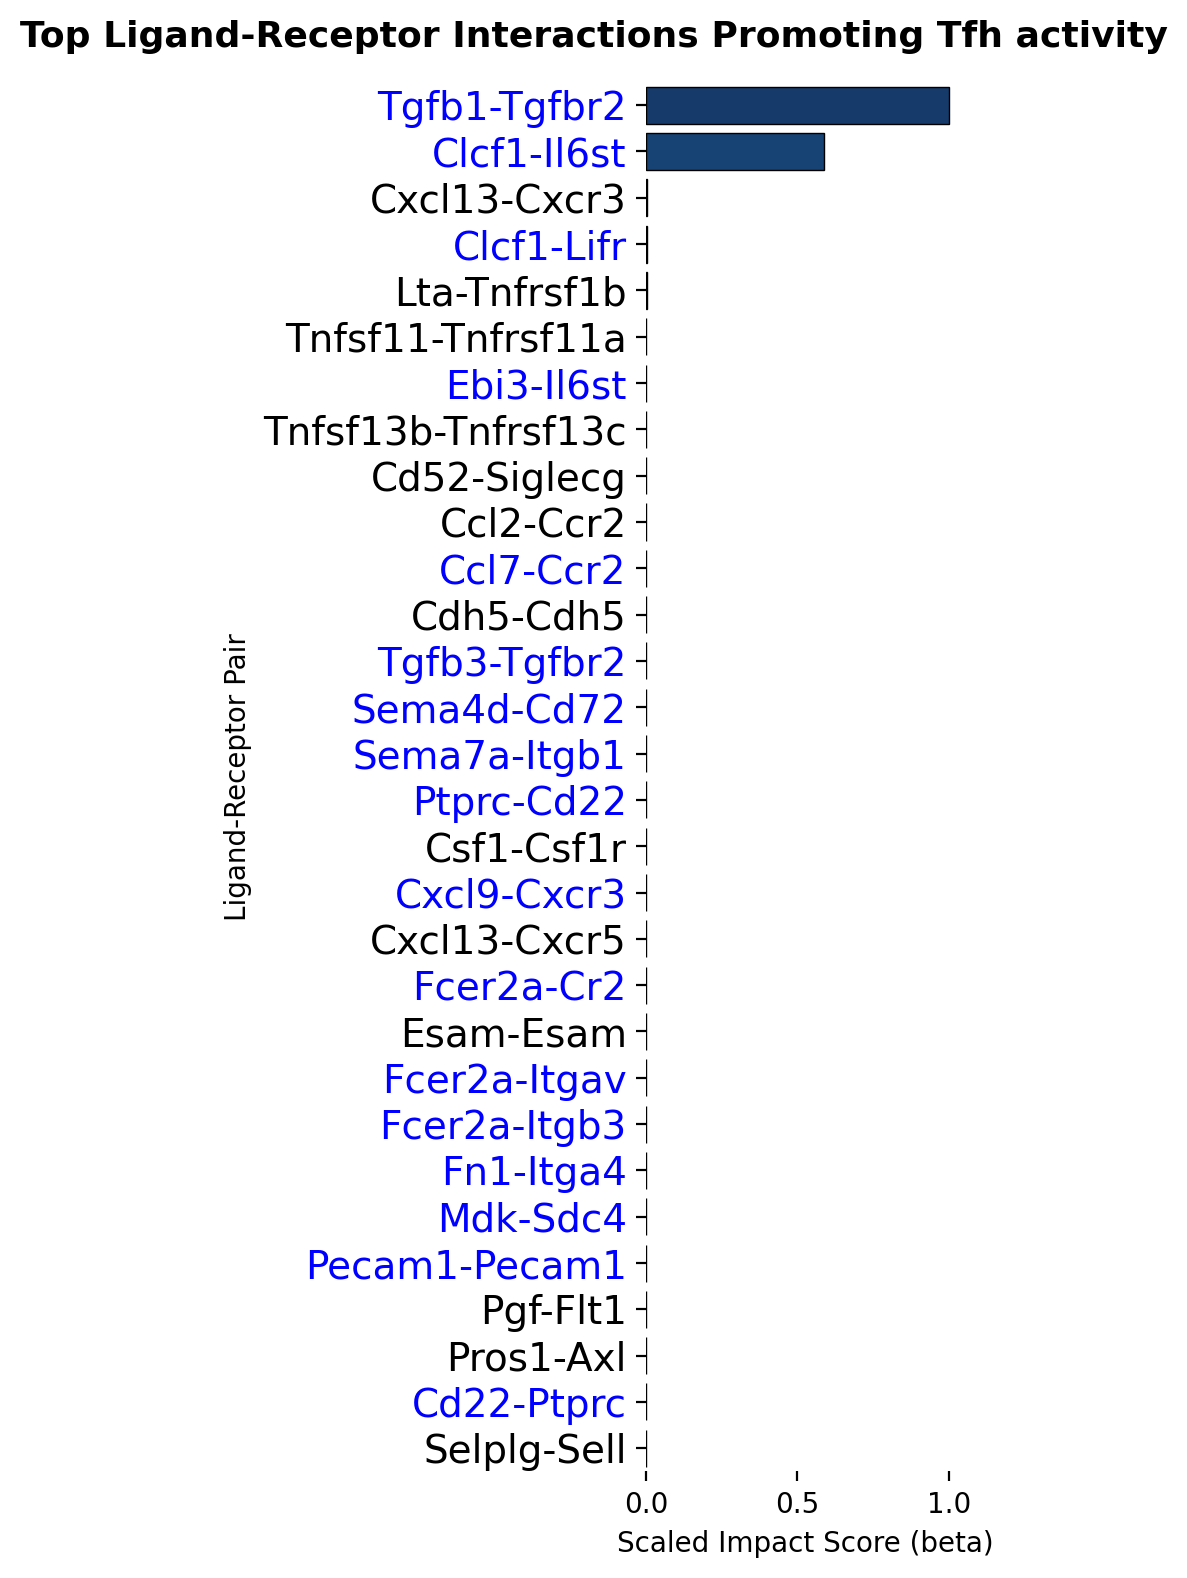

In [59]:
dfr_th2 = wbetas.sum().sort_values(ascending=False).head(30)
dfr_th2 = dfr_th2 / dfr_th2.abs().max()
dfr_th2.index = dfr_th2.index.str.replace('beta_', '')

# Setup figure
fig, ax = plt.subplots(figsize=(4, 8), dpi=200)

# Barplot for Th2
sns.barplot(
    x=dfr_th2.values, 
    y=dfr_th2.index, 
    ax=ax, 
    palette="Blues_r",
    linewidth=0.5,
    edgecolor='black'
)
ax.set_xlabel("Scaled Impact Score (beta)")
ax.set_ylabel("Ligand-Receptor Pair")

for spine in ax.spines.values():
    spine.set_visible(False)

for label in ax.get_yticklabels():
    text = label.get_text()
    for gene in text.split('-'):
        # if gene in target_genes:
        #     # In the key_name definition
        #     label.set_color('#f2832e')
        if gene in set(all_markers) - set(tfh_markers['base_markers']):
            # In one of the networks
            label.set_color('blue')
ax.tick_params(axis='y', labelsize=14)

plt.suptitle(f"Top Ligand-Receptor Interactions Promoting Tfh activity", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'figures/mouse_lymph_visiumHD_{key_name}_LR_interactions_original{suffix}.svg', dpi=300, bbox_inches='tight', transparent=True, format='svg')
plt.show()

In [60]:
dfr_th2.to_csv(f'tables/mouse_lymph_visiumHD_{key_name}_LR_interactions_original{suffix}.csv')